In [4]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import fsps
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fsps.filters import FILTERS

In [5]:
filters = fsps.list_filters()

for f in filters:
    print(f)


v
u
b
buser_b
cousins_r
cousins_i
cfht_b
cfht_r
cfht_i
2mass_j
2mass_h
2mass_ks
sdss_u
sdss_g
sdss_r
sdss_i
sdss_z
wfpc2_f255w
wfpc2_f300w
wfpc2_f336w
wfpc2_f439w
wfpc2_f450w
wfpc2_f555w
wfpc2_f606w
wfpc2_f814w
wfpc2_f850lp
wfc_acs_f435w
wfc_acs_f475w
wfc_acs_f555w
wfc_acs_f606w
wfc_acs_f625w
wfc_acs_f775w
wfc_acs_f814w
wfc_acs_f850lp
wfc3_uvis_f218w
wfc3_uvis_f225w
wfc3_uvis_f275w
wfc3_uvis_f336w
wfc3_uvis_f390w
wfc3_uvis_f438w
wfc3_uvis_f475w
wfc3_uvis_f555w
wfc3_uvis_f606w
wfc3_uvis_f775w
wfc3_uvis_f814w
wfc3_uvis_f850lp
wfc3_ir_f098m
wfc3_ir_f105w
wfc3_ir_f110w
wfc3_ir_f125w
wfc3_ir_f140w
wfc3_ir_f160w
irac_1
irac_2
irac_3
irac_4
isaac_ks
fors_v
fors_r
nicmos_f110w
nicmos_f160w
galex_fuv
galex_nuv
des_g
des_r
des_i
des_z
des_y
wfcam_z
wfcam_y
wfcam_j
wfcam_h
wfcam_k
steidel_un
steidel_g
steidel_rs
steidel_i
megacam_u
megacam_g
megacam_r
megacam_i
megacam_z
wise_w1
wise_w2
wise_w3
wise_w4
uvot_w2
uvot_m2
uvot_w1
mips_24
mips_70
mips_160
scuba_450wb
scuba_850wb
pacs_70
pacs_100
pacs_

In [6]:
# ---------------------------
# Settings
# ---------------------------
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
band_type = "SDSS"
bands = ["sdss_g", "sdss_z"]

snap = 600
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"

# ---------------------------
# FSPS configuration (ONCE)
# ---------------------------
compute_vega_mags = band_type == "JC"

sp = fsps.StellarPopulation(
    imf_type=2,
    zcontinuous=1,
    compute_vega_mags=compute_vega_mags,
)

sp.params["add_dust_emission"] = False
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["dust1"] = 0.0
sp.params["dust2"] = 0.0
sp.params["fcstar"] = 0.0
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0


# ============================================================
# 1) COLLECT ALL (AGE, FEH) ACROSS *ALL* ITERATIONS
# ============================================================
all_ages = []
all_fehs = []
iter_star_counts = []

with h5py.File(ghost_file, "r") as ghost_data:
    for it_id in ghost_data.keys():
        snp_id = gc_utils.snapshot_name(snap)
        snp_dat = ghost_data[it_id]["snapshots"][snp_id]
        src_dat = ghost_data[it_id]["source"]

        gcids = snp_dat["gcid"][()]
        ages = snp_dat["age"][()]  # Gyr

        feh_map = dict(zip(src_dat["gcid"], src_dat["feh"]))
        fehs = np.array([feh_map[g] for g in gcids])

        all_ages.append(ages)
        all_fehs.append(fehs)
        iter_star_counts.append(len(ages))

all_ages = np.concatenate(all_ages)
all_fehs = np.concatenate(all_fehs)

# ============================================================
# 2) BUILD GLOBAL UNIQUE SSP GRID
# ============================================================
ssp_params = np.column_stack((all_ages, all_fehs))
unique_ssps, inv_idx_all = np.unique(ssp_params, axis=0, return_inverse=True)

n_ssp = len(unique_ssps)
print(f"Computing {n_ssp} unique SSPs across all iterations")

# ============================================================
# 3) RUN FSPS ONCE PER UNIQUE SSP
# ============================================================
nband = len(bands)
ssp_mag = np.empty((n_ssp, nband))
ssp_mass = np.empty(n_ssp)

for i, (age, feh) in enumerate(unique_ssps):
    if i % 100 == 0 or i == n_ssp - 1:
        print(f"SSP {i + 1}/{n_ssp}")

    sp.params["logzsol"] = feh
    ssp_mag[i] = sp.get_mags(tage=age, bands=bands)
    ssp_mass[i] = sp.stellar_mass

# (optional but recommended)
# np.savez(
#     "ssp_cache_global.npz",
#     unique_ssps=unique_ssps,
#     ssp_mag=ssp_mag,
#     ssp_mass=ssp_mass,
# )

# ============================================================
# 4) APPLY SSP GRID PER ITERATION (FAST)
# ============================================================

sim_dict = {sim: {}}
offset = 0

with h5py.File(ghost_file, "r") as ghost_data:
    for it_id, nstar in zip(ghost_data.keys(), iter_star_counts):
        snp_id = gc_utils.snapshot_name(snap)
        snp = ghost_data[it_id]["snapshots"][snp_id]

        gcids = snp["gcid"][()]
        mass = 10 ** snp["logm"][()]

        ssp_idx = inv_idx_all[offset : offset + nstar]
        offset += nstar

        scaling = mass / ssp_mass[ssp_idx]
        mags = ssp_mag[ssp_idx] - 2.5 * np.log10(scaling)[:, None]

        sim_dict[sim][it_id] = {
            "gcid": gcids,
            "mag_g": mags[:, 0],
            "mag_z": mags[:, 1],
        }


Computing 8106 unique SSPs across all iterations
SSP 1/8106
SSP 101/8106
SSP 201/8106
SSP 301/8106
SSP 401/8106
SSP 501/8106
SSP 601/8106
SSP 701/8106
SSP 801/8106
SSP 901/8106
SSP 1001/8106
SSP 1101/8106
SSP 1201/8106
SSP 1301/8106
SSP 1401/8106
SSP 1501/8106
SSP 1601/8106
SSP 1701/8106
SSP 1801/8106
SSP 1901/8106
SSP 2001/8106
SSP 2101/8106
SSP 2201/8106
SSP 2301/8106
SSP 2401/8106
SSP 2501/8106
SSP 2601/8106
SSP 2701/8106
SSP 2801/8106
SSP 2901/8106
SSP 3001/8106
SSP 3101/8106
SSP 3201/8106
SSP 3301/8106
SSP 3401/8106
SSP 3501/8106
SSP 3601/8106
SSP 3701/8106
SSP 3801/8106
SSP 3901/8106
SSP 4001/8106
SSP 4101/8106
SSP 4201/8106
SSP 4301/8106
SSP 4401/8106
SSP 4501/8106
SSP 4601/8106
SSP 4701/8106
SSP 4801/8106
SSP 4901/8106
SSP 5001/8106
SSP 5101/8106
SSP 5201/8106
SSP 5301/8106
SSP 5401/8106
SSP 5501/8106
SSP 5601/8106
SSP 5701/8106
SSP 5801/8106
SSP 5901/8106
SSP 6001/8106
SSP 6101/8106
SSP 6201/8106
SSP 6301/8106
SSP 6401/8106
SSP 6501/8106
SSP 6601/8106
SSP 6701/8106
SSP 6801/81

In [7]:
sim_dict[sim][it_id]

{'gcid': array([ 57057454,  62672348, 119239444,  59979388,  55423942,  63991214,
         55422322,  60526850,  49302363,  61221237,  50799673,  38032459,
         38838992,  49495853,  61075317,  50994672,  44816205,  52803143,
         25964649,  49679544,  43619575,  27250510,  25608665,  45809825,
        122048079, 132007718,  30624450,  51912043,  30436542,  52631213,
         61379569,  53180634,  41021398,  63869327,  24878201,  38073532,
         41792985,  31198183,  43408179,  22927365,  25433683,  50437672,
         50605919,  35078490,  53877253,  50457774,  54050442,  39818617,
         41611327,  32148570,  35904745,  39825584,  25591188,  54039517,
         56734649,  61636965,  27300491,  35264113,  54913062,  59817831,
         50073141,  29294238,  59843688,  40626067,  42001493,  55061214,
         25416093,  34330436,  42817730,  49322359,  31777916,  27479389,
         63755970,  33684308,  25630900,  33708825,  28782658,  37892933,
         58775124,  24530715, 

Text(0.5, 0, 'g - z')

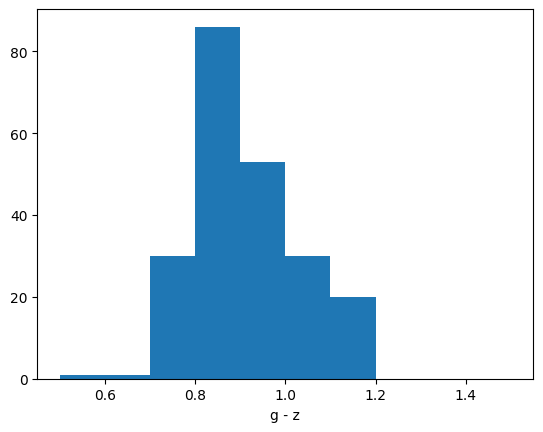

In [8]:
cols = mags[:, 0] - mags[:, 1]
bins = np.arange(0.5, 1.6, 0.1)
plt.hist(cols, bins=bins)
plt.xlabel("g - z")